# 24.3) Configuração do ambiente aprendizagem por reforço com Q-Learning

Ambiente maq2 no anconda 2, no linux

# Aprendizagem por Reforço com Q-Learning

- Código adaptado de: https://www.learndatasci.com/tutorials/reinforcement-q-learning-scratch-python-openai-gym/

In [59]:
#!pip install gym # primeiro passo, está na versão 0.26.2

In [60]:
#!pip uninstall gym

(base) :~$ conda env list

(base) :~$ conda activate Maq2

(Maq2) : pip uninstall gym

Found existing installation: gym 0.26.2


In [61]:
#!pip install gym==0.17.3 # Use esta versão para conseguir visualizar o ambiente

## Entendimento do ambiente

In [62]:
import gym
import random
import os
#os.environ["SDL_VIDEODRIVER"] = "dummy"
gym.__version__

'0.17.3'

In [63]:
env = gym.make('Taxi-v3')

In [64]:
env.reset()
env.render()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



In [65]:
env.render() # local para buscar o taxi

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




Amarelo está vazio o táxi, 

cor verde com passageiro, 

A letra azul onde o passageiro sai de forma inicial, 

e a letra rosa  onde o passageiro tem que chegar. 


A | barreira são os obstáculos , o carro não pode cruzar as barreiras.

In [66]:
env.reset() # resetar e 
env.render() # renderizar novamente, colocando em posições diferentes

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



In [67]:
# espaço de ações

# 6 posições que o agente pode fazer, ações de movimento:
# 0 = south 1 = north 2 = east 3 = west 4 = pickup 5 = dropoff
# pickup- pegar , e dropoff- deixar o passageiro
# pegar e deixar o passageiro:

print(env.action_space)

Discrete(6)


gym.openai.com/envs/Taxi-v3

https://gymnasium.farama.org/

https://www.gymlibrary.dev/environments/toy_text/taxi/#observations

In [68]:
# se pode ter 500 movimentos, pois há 4 destinos, com uma matriz de 5 linhas, e 5 colunas
print(env.observation_space)

Discrete(500)


In [69]:
#5*5*5*4 -- Atualizado 22/11/2022 ref. https://www.gymlibrary.dev/environments/toy_text/taxi/#observations
25*5*4

500

In [70]:
#5*linhas*colunas*possíveis posições do passageiro = total de condição de estados do ambiente 500

In [71]:
# quanto maior a matriz maior o número de estados;

In [72]:
# P variáveis de estados possíveis
len(env.P)

500

In [73]:
#env.P # mostrar todos os estados possíveis, em dicionário

In [74]:
env.P[0]

{0: [(1.0, 100, -1, False)],
 1: [(1.0, 0, -1, False)],
 2: [(1.0, 20, -1, False)],
 3: [(1.0, 0, -1, False)],
 4: [(1.0, 16, -1, False)],
 5: [(1.0, 0, -10, False)]}

In [75]:
env.P[484] # uma dessas ações

{0: [(1.0, 484, -1, False)],
 1: [(1.0, 384, -1, False)],
 2: [(1.0, 484, -1, False)],
 3: [(1.0, 464, -1, False)],
 4: [(1.0, 484, -10, False)],
 5: [(1.0, 484, -10, False)]}

In [76]:
# [(probabilidade), (próximo estado), (recompensa), (indica se o jogo terminou ou não)]
# probabilidade 1.0 sempre 100%
# neste exemplo é um processo determinístico

#### a cada movimento há uma penalidade, no caso -1

isso é para incentivar o caminho mais rápido.

In [77]:
# penalidade maior com -10, quando deixa a pessoa no local errado. 

#### algoritmo tem que aprender no decorer do tempo a fazer ssas melhores rotas

# 24.4) Treinamento 1 Q Learning

Aprendizagem por reforço. 

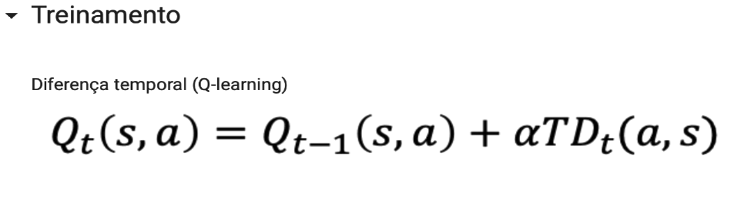

%%time ver a duração do processo

Hiperparâmetros definidos

diferença temporal (Q-learning)


Q=1 e Q =3, tendência sempre é ir no q maior, mas tem que ver a probabilidade. 

 1-10% / 3-90% , conceito exploration(explorar mais caminhos, rotas alternativas)/exploitation (melhor caminho)

### 🔹 Diferença Temporal (TD Error)

O **erro de diferença temporal** mede o quanto a estimativa atual $\( Q(s_t, a_t) \)$ 
difere do retorno esperado com base na recompensa imediata e no valor futuro:

$\[
\delta_t = r_t + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t)
\]$

- $\( r_t \)$: recompensa imediata no tempo \( t \).  
- $\( \gamma \)$: fator de desconto ($( 0 \leq \gamma \leq 1 $)).  
- $\( \max_{a'} Q(s_{t+1}, a') \)$: melhor valor de ação no próximo estado.  
- $\( Q(s_t, a_t) \)$: valor atual estimado.  

---

### 🔹 Atualização do Q-Learning

O Q-learning ajusta o valor da ação com base no erro $\(\delta_t\)$:

$\[
Q(s_t, a_t) \;\leftarrow\; Q(s_t, a_t) + \alpha \cdot \delta_t
\]$

ou seja,

$\[
Q(s_t, a_t) \;\leftarrow\; Q(s_t, a_t) + \alpha 
\Big( r_t + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t) \Big)
\]$

- $\( \alpha \)$: taxa de aprendizado $(\( 0 < \alpha \leq 1 \))$.  

---

### 🔹 Intuição

1. Observa-se uma transição de estado $\( (s_t, a_t, r_t, s_{t+1}) \)$.  
2. Calcula-se a **diferença entre o valor esperado e o observado** $(\(\delta_t\))$.  
3. Atualiza-se $\( Q(s_t, a_t) \)$ movendo-o um pouco na direção do novo valor.  

Assim, o Q-learning combina **aprendizado supervisionado** (corrige a previsão do valor)  
com **aprendizado por reforço** (explora ações e recompensas futuras).


In [78]:
random.uniform(0, 1)

0.13824378057845643

In [79]:
env.action_space # que só apresenta  o número 6

Discrete(6)

In [80]:

import numpy as np
q_table = np.zeros([env.observation_space.n, env.action_space.n])
q_table.shape

# (criando cada um dos movimentos, com 6 colunas-> cada uma das posições)

(500, 6)

In [81]:
q_table

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])

In [82]:
q_table[0]

array([0., 0., 0., 0., 0., 0.])

In [83]:
np.argmax(np.array([3, 5]))
# retorna a posição que tem o menor valor

np.int64(1)

In [84]:
np.argmax(np.array([10, 5]))

np.int64(0)

In [85]:

%%time

from IPython.display import clear_output

#alpha = taxa de aprendizagem
alpha = 0.1
gamma= 0.6 # dentro do Dt fator de desconto
epsilon = 0.1 # probabilidade é 1 para todos, aprendizagem por reforço

# Q=1 e Q =3, tendência sempre é ir no q maior, mas tem que ver a probabilidade. 
# 1-10% / 3-90% , conceito exploration(explorar mais caminhos)/exploitation (melhor caminho)
# 0 = south 1 = north 2 = east 3 = west 4 = pickup 5 = dropoff
# movimento do carro


# ir de 1000 para 100000, o melhor é 10000, pra não demora muito
for i in range(10000): # treinar mil vezes
     # resetar
     estado=env.reset() # retorna o estado inicial encontra o táxi, reinicia aleatoriamente
     # inicialização
     penalidades, recompensa = 0, 0
     done= False # terminou a execução
     # codificar o processo
     while not done:
        # Exploração
        # random gera um número entre 0 e 1 com casas depois da vírgula.
        # só entrará caso o epsilon for menor que 0,1       
        
        if random.uniform(0,1) < epsilon: 
           # ação randomica
           # ação aleatória
           # print(env.action_space) Discrete(6) deixa o passageiro
           acao = env.action_space.sample()

           #q_table tabela, quanto maior melhor
        # Exploitation, seguir sempre para o melhor caminho
        else:
          acao = np.argmax(q_table[estado]) # estado retornado, pegando o maior valor
          # acao = np.argmax(q_table[state, action]), buscar a coluna com o maior valor
         # retornar a ação 0 ou 1, a próxima ação;
         # conceito exploration(explorar mais caminhos, rotas alternativas)/exploitation (melhor caminho, valr maior de probabilidade)

         
        # done finalizado ou não, informação => ação step (ação) buscar a ação. 
        # step agente para executar o processo
         # treinamento para o agente se deslocar
        proximo_estado, recompensa, done, info = env.step(acao)

        # estado e ação passando, 
        q_antigo = q_table[estado, acao]
         # precisamos sempre pegar o maior valor, para analise e ver o caminho melhor
        proximo_maximo = np.max(q_table[proximo_estado])
         
        # Qt = Qt-1 (anterior) + alfa(taxa de aprendizagem)*T*Dt(=>recomensa+gama*maior valor do próximo estado)   
        q_novo = (1 - alpha) * q_antigo + alpha * (recompensa + gamma * proximo_maximo)
        # detalhe para muitas épocas, antigos, problemas de falha de memória, 1-alfa (0,1) => (1 - alpha) * q_antigo 
        #para o q ficar em  uma escala menor. Para evitar ficar com algum tipo de erro. 

        # atualização 
        q_table[estado, acao] = q_novo
         
        # -10 é quando o agente leve a pessoa ao lugar errado.
        # enveto de penalidade +1, igual a 1.
        if recompensa == -10:
          penalidades += 1
            
        # próximo estado, pela ação. 
        estado = proximo_estado
      # se o valor do i%100, valores de 100 em 100 vezes. 
      # clear para apagar, e considerar em episódio. 
     if i % 100 == 0:
        clear_output(wait=True) # para não mostrr as mensagens, uma abaixo da outra. 
        print('Episódio: ', i)

print('Treinamento concluído')     

Episódio:  9900
Treinamento concluído
CPU times: user 1.81 s, sys: 91.5 ms, total: 1.9 s
Wall time: 1.81 s


In [86]:
# conceito exploration(explorar mais caminhos, rotas alternativas)/exploitation (melhor caminho, valr maior de probabilidade)

In [87]:
# ambiente, e cada um é um episódio, leva e tras o passageiro. 
# a ideia é geral o qtable
# para o algoritmo ter poucos erros. 

In [88]:
env.P[484]

{0: [(1.0, 484, -1, False)],
 1: [(1.0, 384, -1, False)],
 2: [(1.0, 484, -1, False)],
 3: [(1.0, 464, -1, False)],
 4: [(1.0, 484, -10, False)],
 5: [(1.0, 484, -10, False)]}

In [89]:
# 0 = south 1 = north 2 = east 3 = west 4 = pickup 5 = dropoff
q_table
# atualizaos por esta fórmula =>  q_novo = (1 - alpha) * q_antigo + alpha * (recompensa + gamma * proximo_maximo)


array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ],
       [-2.35305163, -2.34552075, -2.38761071, -2.34084665, -2.27325184,
        -9.92447948],
       [-1.8226046 , -1.57577482, -1.88132842, -1.50747197, -0.7504    ,
        -9.3159154 ],
       ...,
       [-1.25103298,  0.17216223, -1.25103298, -1.23866238, -2.76649095,
        -1.96      ],
       [-2.01061959, -2.01747742, -2.00971984, -2.01588213, -3.67399572,
        -2.8722641 ],
       [-0.196     , -0.19832603, -0.13317672, 10.84283094, -1.77643795,
        -1.        ]])

In [90]:
# 0 = south 1 = north 2 = east 3 = west 4 = pickup 5 = dropoff
q_table[424] # estado específico


array([ -2.49169213,  -2.49154434,  -2.49148031,  -2.49162035,
       -10.1437785 ,  -5.74494183])

In [91]:
env.render()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)


In [92]:
# não mostra o ponto azul, que é o início

In [93]:
# resetamos para pegar o estado, para pegar a posição
env.reset()
env.render()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



In [94]:
#env.encode(taxi_row localização linha, taxi_col localização do taxi col, pass_loc localização do passageiro, dest_idx localização do destino)
#env.encode(taxi_row, taxi_col, pass_loc, dest_idx)
env.encode(1, 1, 1, 0) # correto
# começa do zero, taxi em amarelo os dois primeiros números
# ponto de origem é o zero, G azul e rosa o final ou destino

# pontos das letras
#0     1
#3     2

124

In [95]:
# indica o encode o valor do estado

In [96]:
# 0 = south 1 = north 2 = east 3 = west 4 = pickup 5 = dropoff
q_table[124] # estado específico

array([-2.48941477, -2.49027475, -2.48941923, -2.48982706, -8.75592922,
       -9.26132906])

In [97]:
env.encode(1, 1, 0, 1)

121

In [98]:
q_table[121] 

array([-2.43847497, -2.41837066, -2.43364347, -2.41837066, -9.63562736,
       -9.80490304])

In [99]:
print(f'{max(q_table[124]):.8f}')

-2.48941477


In [101]:
env.step(0) # melhor ação no melhor valor da posição da direção, no caso o maior valor

(411, -1, False, {'prob': 1.0})

In [102]:
env.render() # já mudou e se posicionou

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)


In [103]:
env.encode(4, 0, 3, 2) # posição nova, estado novo 414

414

In [104]:
q_table[414] 

array([-2.48833746, -2.48818849, -2.4880903 , -2.48851141, -7.97814016,
       -8.09282441])

In [105]:
print(f'{max(q_table[414]):.8f}') # 2 -> east, melhor movimento e o segundo possível é no norte 1

-2.48809030


In [109]:
env.step(1)
env.render()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)


Esse resultado significa que o estado (1,1,1,0) foi transformado em um vetor de 6 dimensões:


s=[−2.489,−2.496,−2.493,−2.495,−10.875,−11.294]

Esse vetor é a forma numérica que o algoritmo de aprendizado por reforço vai usar para:

calcular valores 

Q(s,a),

alimentar a rede neural,

ou medir distâncias entre estados.

Representação de estado contínua

- Esses valores provavelmente representam características do estado (features) após uma transformação (por exemplo, embedding, normalização ou codificação contínua).

Cada número corresponde a uma dimensão do vetor do estado.

Valores negativos indicam que foi usada alguma padronização ou projeção (ex.: média zero).

- Não é o índice do estado
- 
No Taxi-v3 clássico do Gym, env.encode() retorna um inteiro (estado único).
Aqui, o ambiente parece ter sido modificado ou é outro (talvez uma versão customizada), porque está retornando um vetor real em vez de um escalar.

- Possível embedding neural
Muitos ambientes de RL mais modernos representam estados como vetores contínuos de alta dimensão. Esse array pode ser justamente a entrada da rede neural do agente.

Parece que você está em uma variação ou ambiente customizado, onde encode não devolve o índice discreto do estado, mas sim uma representação vetorial contínua (um embedding do estado).
Os números negativos não significam deslocamento direto, mas sim coordenadas em um espaço latente usado pelo algoritmo.



#### Fórmula do encode

o método env.encode(row, col, passender, dest) faz:

##### s = (((row x 5 + col) x 5 + passenger_ x 4) + dest


Exemplo (1,1,1,0)

##### 1 - Primeiro combina linha e coluna (posição do táxi):

_row x 5 + col = 1 x 5 + 6_

##### 2- incluo o destino

_6 x 5  + passenger = 6 x 5 + 1 = 31_

##### 3 - Inclui o destino:

_31 x 4 + dest = 31 x 4 + 0 = 124_

##### Resultado final

_s = 124_ 


ou seja, o estado 1,1,1,0 corresponde ao índice 124 dos 500 possíveis.

Diferença:

env.encode(1,1,1,0) → retorna um único número (124)
Isso é o índice do estado dentro dos 500 possíveis.

O que você mostrou (array([-2.48, -2.49, ..., -11.29]))
vem de um vetor de valores Q(s,a) para esse estado.
Ou seja:


Q(s,a)∀a∈{0,1,2,3,4,5}

No Taxi, há 6 ações possíveis:

0 = South (descer uma linha)

1 = North (subir uma linha)

2 = East (mover para direita)

3 = West (mover para esquerda)

4 = Pickup (pegar passageiro)

5 = Dropoff (deixar passageiro)

Exemplo no seu caso

Esse vetor:


[−2.489,−2.495,−2.492,−2.495,−10.874,−11.294]

significa:

Ir para o Sul: custo esperado ≈ -2.48

Ir para o Norte: custo esperado ≈ -2.49

Ir para o Leste: custo esperado ≈ -2.49

Ir para o Oeste: custo esperado ≈ -2.49

Tentar pegar passageiro: custo esperado ≈ -10.87

Tentar deixar passageiro: custo esperado ≈ -11.29

✅ Ou seja, o algoritmo está dizendo que os movimentos são ruins, mas ainda melhores do que tentar pegar/deixar passageiro na hora errada.

In [ ]:
# menr valor melhor hipótese, 


o ambiente Taxi-v3, o táxi recebe -1 de recompensa por passo até deixar o passageiro no destino corretamente.
Ou seja:

Quanto menor (mais negativo) o Q, pior é o caminho esperado (muitos passos até resolver).
Quanto maior (menos negativo ou positivo), melhor é a ação (menos passos ou sucesso imediato).


	
Ação:South	Valor Q(s,a): -2.489	Interpretação:🟢 Melhor ação (menor penalidade esperada)

Ação:Dropoff	Valor Q(s,a): -11.294	Interpretação:🔴 Muito ruim (não é hora de deixar)

## Avaliação

In [113]:

# faremos a avaliação do algoritmo. 

# total de penalidades
total_penalidades = 0
# cada episódio é um jogo completo
episodios = 50
frames = []

for _ in range(episodios):
# estado inicial randomico.
  estado = env.reset()
  # no começo a penalidade e recompensa recebem os dados zerados
  penalidades, recompensa = 0, 0
  # done é para finalizar ou começar o processo
  done = False
  # enquanto não está finalizado
  while not done:
    # escolher a manifestação, pegar o maior valor de probabilidades
    # acessando a matriz
    acao = np.argmax(q_table[estado])
    # movimentar o agente
    # # env.step e env.render
    estado, recompensa, done, info = env.step(acao)
    # recompensa táxi leva o passageiro ao lugar errado = -10
    if recompensa == -10:
      # incrementa o número de penalidades.
      penalidades += 1
        
    # armazenar cada um dos estados e depois nós fazermos o desenho frames ponto apêndice.
    frames.append({
        'frame': env.render(mode='ansi'), # para visualizar a animação
        'state': estado,
        'action': acao,
        'reward': recompensa
    })

  total_penalidades += penalidades  # incrementar a penalidade

print('Episódios', episodios)
print('Penalidades', total_penalidades) # quantas vezes o táxi levou a pessoa para o local errado.


Episódios 50
Penalidades 0


In [111]:
frames[0]

{'frame': '+---------+\n|R: | : :\x1bG\x1b|\n| : | : : |\n| : : :\x1b \x1b: |\n| | : | : |\n|Y| : |\x1bB\x1b: |\n+---------+\n  (East)\n',
 'state': 273,
 'action': np.int64(2),
 'reward': -1}

In [112]:
frames[1]

{'frame': '+---------+\n|R: | : :\x1bG\x1b|\n| : | : : |\n| : : : : |\n| | : |\x1b \x1b: |\n|Y| : |\x1bB\x1b: |\n+---------+\n  (South)\n',
 'state': 373,
 'action': np.int64(0),
 'reward': -1}

In [114]:
from time import sleep
for frame in frames:
  clear_output(wait=True)
  print(frame['frame'])
  print('Estado', frame['state'])
  print('Ação', frame['action'])
  print('Recompensa', frame['reward'])
  sleep(.5) # aumentar o tempo da amostra

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)

Estado 0
Ação 5
Recompensa 20


nesta aprendizagem de dados, não precisamos de ter os dados completos, mas usando o qlearning, consguimos fazer. Sem ter penalidades. Aprendizagem por reforço.